<div style="background:#2b2b3a;color:#fff;padding:18px 22px;border-radius:8px;font-family:system-ui">
<h1 style="margin:0">VRP Backtest — Iteration 4: Robustness</h1>
<p style="margin:6px 0 0;opacity:.9">Stress-tests of the deployed macro short-vol <b>WINNER</b> — SPX bull put spread,
sell 0.25Δ / buy 0.125Δ put, ~30 trading-day hold to expiry, weekly entry, <code>ramp+</code>
vrp-z sizing — each benchmarked against the <b>iteration-3 SPX base case</b> and <b>SPY buy-and-hold</b>.</p>
</div>

**What this measures.** All values are the **annualised monthly-return Sharpe ratio**
(`mean(monthly return) / std(monthly return) × √12`) unless a column says otherwise.
Data: SPX + VIX (`vol_index_daily`, 2006→2026-05), SPY spot from the lake.
**Reproduce:** `uv run python scripts/research/vrp_robustness_run.py` (SEED=20260623),
`scripts/research/vrp_trade_log.py` for the fills. Full traces: `docs/research/vrp/iter4-*.csv`.

**The strategy, exactly.** *Entry:* every 5 trading days, only when `vrp_z > 0` (vol rich vs its
trailing-252 baseline); size `w = clamp(vrp_z/0.5, 0, 1)`. Sell the 0.25Δ put, buy the 0.125Δ put
(flat-vol Black-Scholes, T=30/252). *Sizing:* `floor(w × risk% × capital / max-loss)` integer
contracts, capital-capped. *Exit:* held to expiry — 30 trading days later, settled at intrinsic;
the long wing is the defined-risk stop (no profit-take, no stop-loss).


In [1]:
import csv
import pathlib

import matplotlib.pyplot as plt
from IPython.display import HTML, display

DATA = next(p for p in [pathlib.Path("docs/research/vrp"), pathlib.Path(".")]
            if (p / "iter4-mc.csv").exists())


def load(name):
    with (DATA / name).open() as fh:
        return list(csv.DictReader(fh))


def f(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return float("nan")


def htable(header, rows, align="right"):
    """Styled HTML table — renders richly in the notebook and in the exported HTML."""
    th = "".join(
        f"<th style='padding:5px 12px;text-align:{align};background:#2b2b3a;"
        f"color:#fff;border:1px solid #444'>{h}</th>" for h in header)
    body = ""
    for i, row in enumerate(rows):
        bg = "#f4f4f8" if i % 2 else "#ffffff"
        tds = "".join(
            f"<td style='padding:4px 12px;text-align:{align};"
            f"border:1px solid #e3e3e3'>{c}</td>" for c in row)
        body += f"<tr style='background:{bg}'>{tds}</tr>"
    return HTML(
        "<table style='border-collapse:collapse;font-family:ui-monospace,Menlo,"
        f"monospace;font-size:12.5px;margin:8px 0'><thead><tr>{th}</tr></thead>"
        f"<tbody>{body}</tbody></table>")


ep = load("iter4-extra-position.csv")
wd = load("iter4-weekday.csv")
bs = load("iter4-bear-start.csv")
bpath = load("iter4-bear-start-path.csv")
mc = load("iter4-mc.csv")
mct = load("iter4-mc-trials.csv")
mincap = load("iter4-min-capital.csv")
log = load("iter4-trade-log.csv")

BASE = next(r for r in ep if r["variant"] == "baseline_iter3_spx")
SPY = next(r for r in ep if r["variant"] == "baseline_spy_buyhold")
BASE_SH, SPY_SH = f(BASE["sharpe"]), f(SPY["sharpe"])
print(f"reconciliation: base_noncomp == iteration-3 base Sharpe {BASE_SH:.3f}  "
      f"|  SPY buy-hold {SPY_SH:.3f}  |  {len(log)} real fills loaded")


reconciliation: base_noncomp == iteration-3 base Sharpe 1.680  |  SPY buy-hold 0.620  |  470 real fills loaded


## §0 · Smallest viable capital — two answers

SPX spread max-loss **rises ~15× over 2007→2026** with spot. The smallest capital to *start*
trading in 2006 (~\$10k at 20% risk) goes **dormant by ~2015** — it can't afford a recent
spread. The honest account size is the **trade-throughout** column. *Defined-risk SPX
vol-selling is a six-figure-capital strategy.*


In [2]:
# §0 Smallest viable capital
hdr = ["risk/spread", "first max-loss", "max max-loss", "start floor (2006)", "trade-throughout"]
rows = [[f"{f(r['risk_pct']):.0%}", f"${f(r['first_mlpc']):,.0f}", f"${f(r['max_mlpc']):,.0f}",
         f"${f(r['c0_floor_start']):,.0f}", f"<b>${f(r['c0_floor_throughout']):,.0f}</b>"] for r in mincap]
display(htable(hdr, rows))


risk/spread,first max-loss,max max-loss,start floor (2006),trade-throughout
10%,"$1,819","$28,408","$19,000","$285,000"
20%,"$1,819","$28,408","$10,000","$143,000"
50%,"$1,819","$28,408","$4,000","$57,000"
100%,"$1,819","$28,408","$2,000","$29,000"


## §1 · Extra position when rich — exposure, not edge

Three arms × {non-compounding, compounding} on the \$143k account. **Reading it:**

- The **staggered second entry** marginally *improves* Sharpe (1.705 vs 1.680); the same-day
  **contract overlay** marginally *hurts* it (1.668) — both add exposure, **not** risk-adjusted edge,
  and deepen the drawdown by ~\$40k.
- **The hidden killer is utilisation.** At 20%/spread × ~6 concurrent slots the book runs ~100%
  deployed (`util_peak = 1.00`), so the 2008 GFC produces a **−90% drawdown on the base** and
  **>−100% on the extra-position arms** (the account briefly goes negative — a ruin event). The
  capital-blind Sharpe completely masks this. Size to **≤ ~16%/spread** to stay under the cap.
- **Compounding** lifts CAGR to ~57% but *lowers* Sharpe (1.46) and scales the dollar drawdown to
  the (enormous) equity — `util_peak` 466× = deployed margin ÷ *initial* capital (leverage-vs-start,
  not a cap breach). The iteration-3 "fantasy" confirmed.


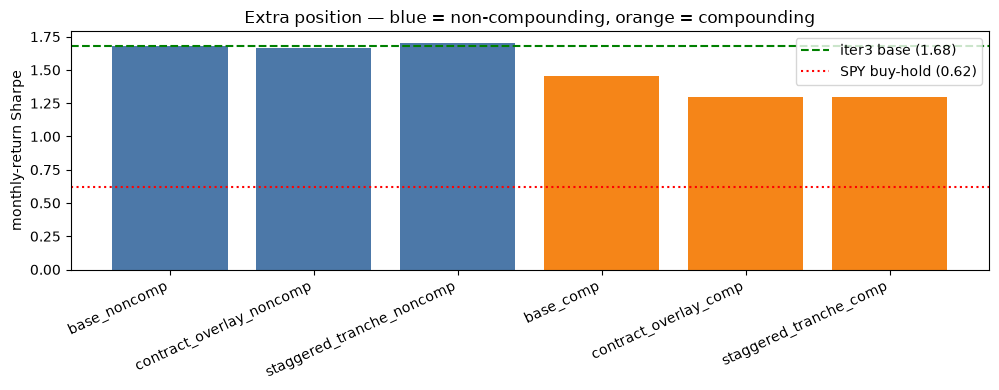

variant,Sharpe,CAGR,maxDD %cap,maxDD $,util_peak,win%,breach%,n
base_noncomp,1.680,13.6%,-90%,"$-128,506",1.00,91%,11%,470
contract_overlay_noncomp,1.668,14.3%,-117%,"$-166,932",1.00,91%,11%,448
staggered_tranche_noncomp,1.705,14.3%,-118%,"$-168,821",1.00,91%,11%,518
base_comp,1.457,57.0%,-98113%,"$-140,301,890",4662.97,90%,13%,508
contract_overlay_comp,1.297,53.3%,-123905%,"$-177,184,550",2986.95,90%,13%,479
staggered_tranche_comp,1.294,50.5%,-87333%,"$-124,886,073",2106.37,90%,12%,537
baseline_iter3_spx,1.680,13.6%,-90%,"$-128,506",1.00,91%,11%,470
baseline_spy_buyhold,0.620,8.8%,-82%,"$-116,592",—,—,—,—


In [3]:
# §1 Extra position — Sharpe by variant vs the two baselines
order = ["base_noncomp", "contract_overlay_noncomp", "staggered_tranche_noncomp",
         "base_comp", "contract_overlay_comp", "staggered_tranche_comp"]
rows = {r["variant"]: r for r in ep}
vals = [f(rows[v]["sharpe"]) for v in order]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(order)), vals, color=["#4c78a8"] * 3 + ["#f58518"] * 3)
ax.axhline(BASE_SH, color="green", ls="--", label=f"iter3 base ({BASE_SH:.2f})")
ax.axhline(SPY_SH, color="red", ls=":", label=f"SPY buy-hold ({SPY_SH:.2f})")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("monthly-return Sharpe")
ax.set_title("Extra position — blue = non-compounding, orange = compounding")
ax.legend()
plt.tight_layout()
plt.show()

hdr = ["variant", "Sharpe", "CAGR", "maxDD %cap", "maxDD $", "util_peak", "win%", "breach%", "n"]
trows = []
for v in order + ["baseline_iter3_spx", "baseline_spy_buyhold"]:
    r = rows[v]
    cagr = f(r["cagr"]) if r["cagr"] else f(r["cagr_excess"])
    trows.append([v, f"{f(r['sharpe']):.3f}", f"{cagr:.1%}", f"{f(r['maxdd_pct']):.0%}",
                  f"${f(r['maxdd_dollars']):,.0f}" if r["maxdd_dollars"] else "—",
                  f"{f(r['util_peak']):.2f}" if r["util_peak"] else "—",
                  f"{f(r['win_rate']):.0%}" if r["win_rate"] else "—",
                  f"{f(r['breach_rate']):.0%}" if r["breach_rate"] else "—", r["n_rungs"] or "—"])
display(htable(hdr, trows, align="right"))


## §2 · Does entry weekday matter? — modestly

Single-weekday Sharpes span **1.33 (Fri) → 1.53 (Tue)** (~0.2 spread) and **all sit below the
natural 5-day stride (1.65)**. So the entry day has a real but modest effect, committing to a fixed
weekday is slightly *worse* than the stride (which diversifies day-of-week exposure), and the edge
stays robustly **> 1.3 on every weekday**.


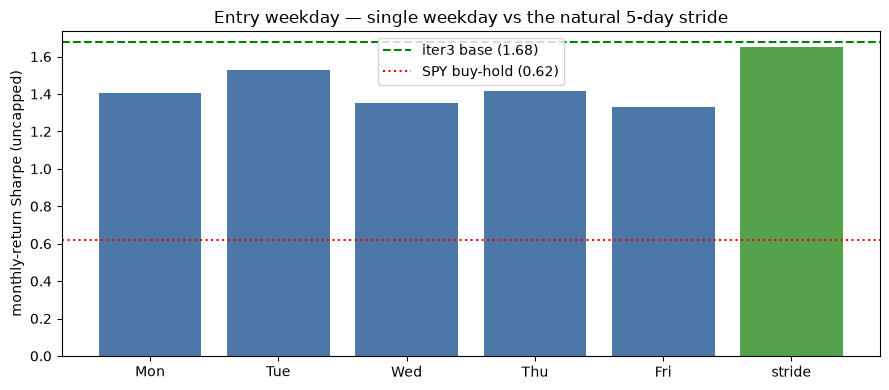

In [4]:
# §2 Entry weekday (uncapped clean-signal basis)
labels = ["weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_stride"]
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "stride"]
unc = {r["variant"].replace("_uncapped", ""): r for r in wd if r["basis"] == "uncapped"}
vals = [f(unc[lab]["sharpe"]) for lab in labels]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(days, vals, color=["#4c78a8"] * 5 + ["#54a24b"])
ax.axhline(BASE_SH, color="green", ls="--", label=f"iter3 base ({BASE_SH:.2f})")
ax.axhline(SPY_SH, color="red", ls=":", label=f"SPY buy-hold ({SPY_SH:.2f})")
ax.set_ylabel("monthly-return Sharpe (uncapped)")
ax.set_title("Entry weekday — single weekday vs the natural 5-day stride")
ax.legend()
plt.tight_layout()
plt.show()


## §3 · Starting at a bear-market top — *helps*, doesn't hurt

Run the strategy forward from each top. **Every bear-start beats the full-history base
(Sharpe 1.87–2.58 vs 1.68)**, delivering **+150–180% over 36 months**. Selling into elevated
post-shock vol harvests rich premium on the recovery — starting at the "worst" time is, counter-
intuitively, *advantageous* for a short-vol harvester. (Entry-day drawdown risk from §1 still
applies if you are already positioned when the shock hits.)


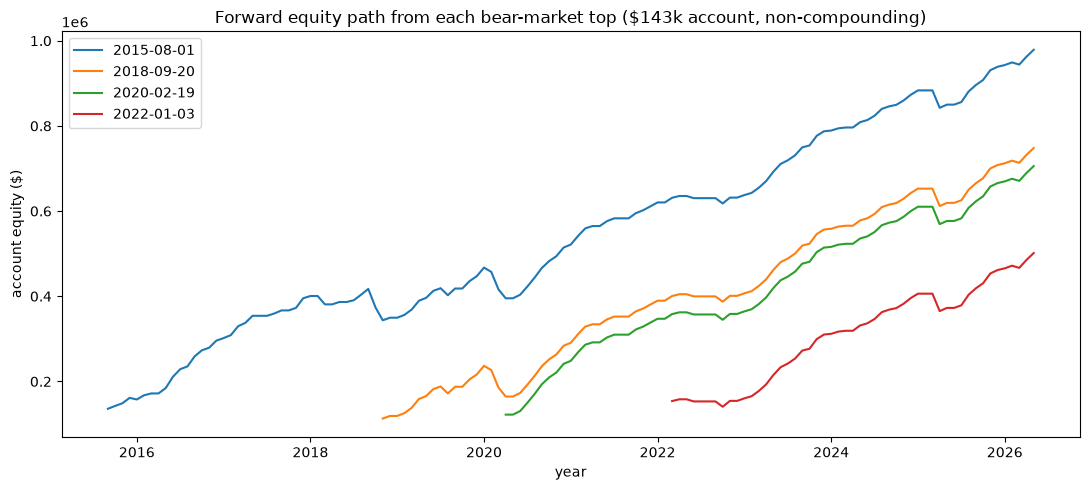

start,n,Sharpe,CAGR,+6m,+12m,+36m
2015-08-01,260,1.87,19.6%,+17%,+65%,+182%
2018-09-20,184,1.92,24.4%,+11%,+31%,+155%
2020-02-19,146,2.58,29.5%,+35%,+100%,+167%
2022-01-03,100,2.34,34.3%,+7%,+16%,+184%


In [5]:
# §3 Bear-market start — full equity path from each bear top
starts = sorted({r["start"] for r in bpath})
fig, ax = plt.subplots(figsize=(11, 5))
for st in starts:
    pts = [r for r in bpath if r["start"] == st]
    x = [int(r["year"]) + (int(r["month"]) - 1) / 12 for r in pts]
    ax.plot(x, [f(r["equity"]) for r in pts], label=st)
ax.set_xlabel("year")
ax.set_ylabel("account equity ($)")
ax.set_title("Forward equity path from each bear-market top ($143k account, non-compounding)")
ax.legend()
plt.tight_layout()
plt.show()

hdr = ["start", "n", "Sharpe", "CAGR", "+6m", "+12m", "+36m"]
trows = [[r["variant"].replace("bear_", ""), r["n_rungs"], f"{f(r['sharpe']):.2f}",
          f"{f(r['cagr']):.1%}", f"{f(r['ret_6m']):+.0%}", f"{f(r['ret_12m']):+.0%}",
          f"{f(r['ret_36m']):+.0%}"] for r in bs if r["variant"].startswith("bear_")]
display(htable(hdr, trows))


## §4 · Monte-Carlo robustness — *not* an overfit

Each driver re-runs the backtest (or resamples its monthly returns) hundreds of times; the columns
are the distribution of the resulting Sharpe. **The headline:** perturbing the tuned knobs
(short_delta 0.20–0.30, hold 20–40d, ramp_full_z 0.3–0.7) holds Sharpe at **p5 = 1.05** — the edge
is **not a knife-edge of the specific config**. Entry-timing jitter (p5 1.19) and the bootstrap CI
[1.05, 2.54] corroborate, and entering short-vol *during* the 2007–09 GFC still clears **p5 1.62**.
Every distribution's p5 sits far above SPY buy-hold (0.62).


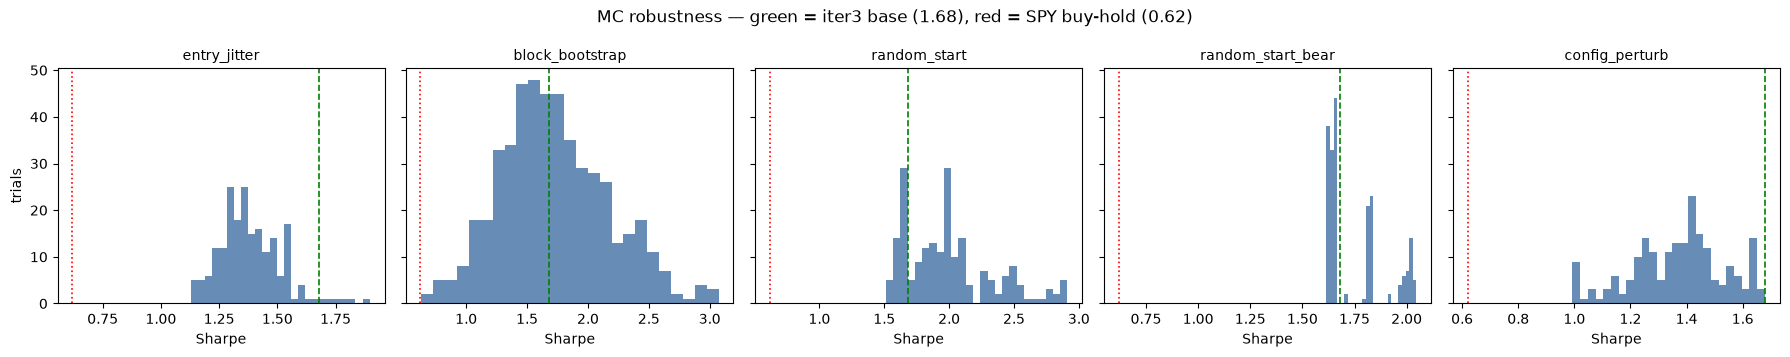

driver,metric,n,mean,p5,median,p95
entry_jitter,sharpe,200,1.385,1.194,1.369,1.597
block_bootstrap,sharpe_bootstrap,500,1.721,1.050,1.671,2.537
random_start,sharpe,200,2.000,1.604,1.969,2.727
random_start_bear,sharpe,200,1.750,1.618,1.652,2.020
config_perturb,sharpe,200,1.371,1.051,1.390,1.643


In [6]:
# §4 Monte-Carlo — trial distributions vs the two baseline Sharpes
tests = ["entry_jitter", "block_bootstrap", "random_start", "random_start_bear", "config_perturb"]
fig, axes = plt.subplots(1, len(tests), figsize=(18, 3.6), sharey=True)
for ax, test in zip(axes, tests):
    vals = [f(r["value"]) for r in mct if r["test"] == test]
    vals = [v for v in vals if v == v]
    ax.hist(vals, bins=25, color="#4c78a8", alpha=0.85)
    ax.axvline(BASE_SH, color="green", ls="--", lw=1.2)
    ax.axvline(SPY_SH, color="red", ls=":", lw=1.2)
    ax.set_title(test, fontsize=10)
    ax.set_xlabel("Sharpe")
axes[0].set_ylabel("trials")
fig.suptitle("MC robustness — green = iter3 base (1.68), red = SPY buy-hold (0.62)")
plt.tight_layout()
plt.show()

hdr = ["driver", "metric", "n", "mean", "p5", "median", "p95"]
trows = [[r["test"], r["metric"], r["n_valid"], f"{f(r['mean']):.3f}", f"<b>{f(r['p5']):.3f}</b>",
          f"{f(r['median']):.3f}", f"{f(r['p95']):.3f}"] for r in mc if r["test"] in tests]
display(htable(hdr, trows))


## §5 · The actual fills — GFC 2008 and Bear 2022

The real backtested trades (engine-faithful: 470 fills, 91.1% win, 11.3% breach, +\$1.47M total).
**The lesson is in the 2008 breaches:** the three big losses came from **late-May / early-June 2008
entries when VIX was only 17–18** — `vrp_z` was positive (rich *vs trailing year*) but **absolute**
vol was low, right before the summer plunge. Selling "rich-vs-trailing" does **not** protect against
a low-absolute-vol regime that then cracks. 2022 (entries at VIX 25–32) was net positive. Note the
contracts shrink from 5–8 (2008, SPX ~1300) to 1–2 (2022, SPX ~4000) — the capital-intensity
finding made concrete.

*How to read one row — `2008-05-30`:* SPX 1400, VIX 17.8 → sell the 1352 put / buy the 1313 put
(39-pt wide), collect \$6,212 on 8 contracts, hold to the 2008-07-14 expiry → SPX settled at 1228
(below 1352 → breached) → **−\$25,323**.


In [7]:
# §5 Actual fills — GFC 2008 and Bear 2022 (real backtested trades)
def fills(year):
    sub = [r for r in log if r["entry_date"][:4] == str(year)]
    hdr = ["entry", "spot", "VIX", "vrp_z", "w", "K_short", "K_long",
           "credit $", "ctr", "exit", "S_T", "breach", "net P&L $"]
    rows = [[r["entry_date"], f"{f(r['spot']):.0f}", f"{f(r['vix']):.1f}",
             f"{f(r['vrp_z']):.2f}", f"{f(r['w']):.2f}", f"{f(r['short_put']):.0f}",
             f"{f(r['long_put']):.0f}", f"{f(r['credit_usd']):,.0f}", r["contracts"],
             r["exit_date"], f"{f(r['exit_spot']):.0f}",
             ("<b style='color:#c0392b'>Y</b>" if r["breached"] == "True" else "·"),
             (f"<b style='color:#c0392b'>{f(r['net_pnl_usd']):,.0f}</b>"
              if f(r["net_pnl_usd"]) < 0 else f"{f(r['net_pnl_usd']):,.0f}")] for r in sub]
    net = sum(f(r["net_pnl_usd"]) for r in sub)
    nbr = sum(1 for r in sub if r["breached"] == "True")
    return hdr, rows, net, nbr, len(sub)

for yr in (2008, 2022):
    h, rows, net, nbr, n = fills(yr)
    display(HTML(f"<h4 style='margin:10px 0 2px'>{yr} — {n} fills, "
                 f"net ${net:,.0f}, {nbr} breached</h4>"))
    display(htable(h, rows))


entry,spot,VIX,vrp_z,w,K_short,K_long,credit $,ctr,exit,S_T,breach,net P&L $
2008-01-07,1416,23.8,0.99,1.00,1351,1299,"6,360",6,2008-02-20,1360,·,"6,037"
2008-01-14,1416,22.9,0.43,0.87,1353,1303,"6,111",6,2008-02-27,1380,·,"5,801"
2008-01-22,1310,31.0,2.29,1.00,1232,1171,"6,484",5,2008-03-05,1334,·,"6,159"
2008-01-29,1362,27.3,0.26,0.52,1290,1234,"3,537",3,2008-03-12,1309,·,"3,359"
2008-02-20,1360,24.4,0.19,0.37,1296,1245,"2,091",2,2008-04-03,1369,·,"1,985"
2008-02-27,1380,22.7,0.28,0.56,1319,1271,"3,932",4,2008-04-10,1361,·,"3,732"
2008-03-05,1334,24.6,1.73,1.00,1270,1220,"7,237",7,2008-04-17,1366,·,"6,870"
2008-03-12,1309,27.2,0.44,0.88,1240,1186,"5,642",5,2008-04-24,1389,·,"5,357"
2008-05-01,1409,18.9,0.12,0.24,1358,1317,"1,658",2,2008-06-13,1360,·,"1,573"
2008-05-22,1394,18.1,0.40,0.80,1346,1307,"5,481",7,2008-07-07,1252,Y,"-22,315"


entry,spot,VIX,vrp_z,w,K_short,K_long,credit $,ctr,exit,S_T,breach,net P&L $
2022-01-20,4483,25.6,1.14,1.00,4260,4085,"7,244",2,2022-03-04,4329,·,"6,889"
2022-01-27,4327,30.5,2.64,1.00,4072,3873,"4,205",1,2022-03-11,4204,·,"4,000"
2022-03-04,4329,32.0,1.00,1.00,4062,3854,"4,426",1,2022-04-18,4392,·,"4,211"
2022-04-25,4296,27.0,0.55,1.00,4071,3894,"7,351",2,2022-06-07,4161,·,"6,991"
2022-05-02,4155,32.3,0.33,0.66,3897,3695,"4,300",1,2022-06-14,3735,Y,"-12,031"
2022-09-01,3967,25.6,0.31,0.61,3770,3615,"3,201",1,2022-10-14,3583,Y,"-12,451"
2022-09-23,3693,29.9,0.44,0.89,3480,3313,"3,519",1,2022-11-04,3771,·,"3,347"
2022-09-30,3586,31.6,0.74,1.00,3367,3197,"7,245",2,2022-11-11,3993,·,"6,891"
2022-10-14,3583,32.0,0.30,0.61,3362,3190,"3,669",1,2022-11-28,3964,·,"3,489"
2022-12-12,3991,25.0,0.97,1.00,3797,3644,"6,292",2,2023-01-26,4060,·,"5,984"


## §6 · Look-ahead audit & bottom line

**Look-ahead audit.** Every entry input is known at the entry-day close: `vrp_z` (trailing-252
z-score), `rv` (trailing-20 realized vol), IV (contemporaneous VIX). Settlement walks the realised
forward path — the *outcome* of a decision already made, not an input. The only forward-looking risk
is in-sample config selection, which §4's config-perturbation quantifies (survives, p5 1.05).

**Bottom line.**
1. **The signal is robust** — Sharpe ≥ 1.0 at p5 across jitter / bootstrap / config; bear-starts *help*.
2. **The extra-position arms don't earn their risk** — skip them.
3. **The real risk is utilisation, not the signal** — a fully-deployed book takes a −90%→>−100% GFC
   drawdown the Sharpe hides. Size under the cap or accept ruin risk.
4. **Capital reality** — ~\$143k to trade SPX spreads at a sane 20% risk; compounding is a CAGR
   mirage that worsens Sharpe.
